In [3]:
! npm i github:daily-co/raw-tracks-tools

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
added 2 packages in 2s
⠙

In [94]:
import glob
import json, subprocess, pathlib
import pandas as pd
import matplotlib.pyplot as plt

In [88]:
video_files = glob.glob("recordings/**/*-video-*.webm")
len(video_files)

571

In [43]:


project_root = pathlib.Path(".")  # where node_modules lives


def get_length_and_missing(video_file):
    video_path = pathlib.Path(video_file).resolve()


    node_snippet = r"""
    import { analyzeTrack } from './node_modules/@daily-co/raw-tracks-tools/src/analyze-track.js';
    const input = process.argv[1];
    const res = await analyzeTrack('py', input, { minGapDurationInSecs: 0.5 });
    console.log(JSON.stringify(res));
    """

    cmd = ["node", "--input-type=module", "-e", node_snippet, str(video_path)]
    res = subprocess.run(cmd, cwd=project_root, capture_output=True, text=True, check=True)
    obj_str = res.stdout.split("\n")[1]
    analysis = json.loads(obj_str) 

    start = analysis["startTime"]
    end = analysis["endTime"]
    gaps = analysis["gaps"]

    def missing_duration(start, end, gaps):
        total = 0.0
        for g in gaps:
            gs, ge = float(g["start"]), float(g["end"])
            # overlap with [start, end]
            clipped_start = max(gs, start)
            clipped_end = min(ge, end)
            if clipped_end > clipped_start:
                total += clipped_end - clipped_start
        return total

    length = end - start
    missing = missing_duration(start, end, gaps)

    return length, missing

length, missing = get_length_and_missing(video_files[2])



In [90]:
if df is None:
    df = pd.DataFrame(columns=["video_file", "length", "missing", "missing_fraction"])

for video_file in video_files:
    if video_file in df["video_file"].values:
        continue
    length, missing = get_length_and_missing(video_file)
    df.loc[len(df)] = [video_file, length, missing, missing / length if length > 0 else 0]

df

,video_file,length,missing,missing_fraction
0,recordings/20250915_2010_pilotC3XTXF/175797028...,99.995,0.000,0.000000
1,recordings/20250915_2010_pilotC3XTXF/175797004...,146.721,0.000,0.000000
2,recordings/20250915_2010_pilotC3XTXF/175797004...,146.971,0.000,0.000000
3,recordings/20250915_2010_pilotC3XTXF/175796983...,109.267,0.000,0.000000
4,recordings/20250915_2010_pilotC3XTXF/175797028...,100.882,0.000,0.000000
...,...,...,...,...
566,recordings/20251117_1839_prolif4SKKED/17634070...,472.271,17.670,0.037415
567,recordings/20251117_1839_prolif4SKKED/17634070...,423.357,43.302,0.102282
568,recordings/20251118_1823_prolifQYS9J0/17634936...,251.418,13.664,0.054348
569,recordings/20251118_1823_prolifQYS9J0/17634936...,257.849,1.723,0.006682


In [ ]:

df.sort_values("missing", ascending=False)["video_file"][0]



'recordings/20250915_2010_pilotC3XTXF/1757970285266-649aa2b6-0ebf-4b78-a73e-7da2ed98d3cb-cam-video-1757970286079.webm'

<Axes: title={'center': 'Video Length Distribution'}, xlabel='video length (minutes)', ylabel='count'>

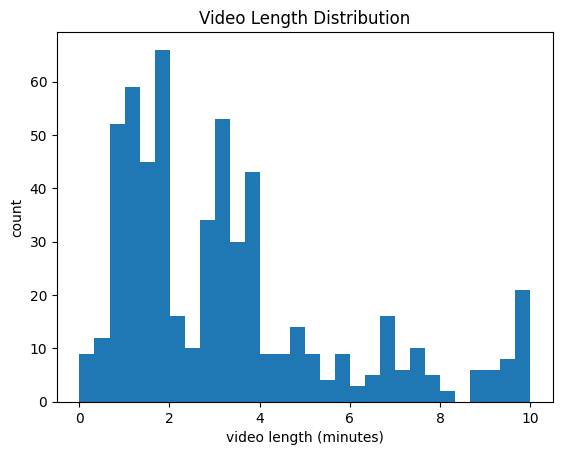

In [105]:
(df["length"]/60).plot(kind="hist", ylabel="count", xlabel="video length (minutes)", bins=30, title=f'Video Length Distribution')

/var/folders/2l/3kmvzs0s1sggnw_9sl0ls8080000gn/T/ipykernel_70353/2407513319.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["missing_fraction"].fillna(0, inplace=True)


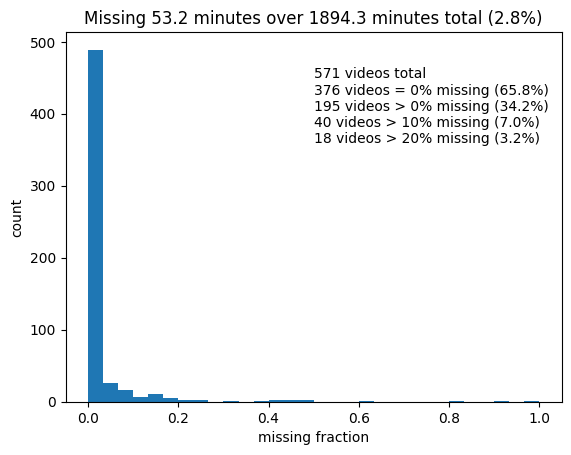

In [104]:
df["missing_fraction"] = df["missing"] / df["length"]
df["missing_fraction"].fillna(0, inplace=True)
df["missing_fraction"].plot(
    kind="hist", ylabel="count", xlabel="missing fraction", bins=30, 
    title=f'Missing {df["missing"].sum()/60:.1f} minutes over {df["length"].sum()/60:.1f} minutes total ({(df["missing"].sum()/df["length"].sum())*100:.1f}%)'
);
plt.annotate(
    f"{len(df)} videos total\n"
    f"{(df['missing'] == 0).sum()} videos = 0% missing ({(df['missing'] == 0).sum()/len(df)*100:.1f}%)\n"
    f"{(df['missing_fraction'] > 0).sum()} videos > 0% missing ({(df['missing_fraction'] > 0).sum()/len(df)*100:.1f}%)\n"
    f"{(df['missing_fraction'] > 0.1).sum()} videos > 10% missing ({(df['missing_fraction'] > 0.1).sum()/len(df)*100:.1f}%)\n"
    f"{(df['missing_fraction'] > 0.2).sum()} videos > 20% missing ({(df['missing_fraction'] > 0.2).sum()/len(df)*100:.1f}%)",
    xy=(0.5, 0.7), xycoords='axes fraction'
);



In [87]:
(df["missing_fraction"] > 0.1).mean()

0.071875

In [70]:
(df["missing"].sum()/60) / (df["length"].sum()/60)

0.019783055938364

In [16]:
res.stdout

'cmd:  ffprobe -hide_banner -show_frames -show_streams /Users/jamesphoughton/github/exaptation/recordings/20250915_2010_pilotC3XTXF/1757970285266-649aa2b6-0ebf-4b78-a73e-7da2ed98d3cb-cam-video-1757970286079.webm\n{"streamMetadata":{"index":0,"codec_name":"vp8","codec_long_name":"On2 VP8","profile":"0","codec_type":"video","codec_tag_string":"[0][0][0][0]","codec_tag":"0x0000","width":640,"height":360,"coded_width":1280,"coded_height":720,"closed_captions":"0","film_grain":"0","has_b_frames":"0","sample_aspect_ratio":"1:1","display_aspect_ratio":"16:9","pix_fmt":"yuv420p","level":"-99","color_range":"unknown","color_space":"unknown","color_transfer":"unknown","color_primaries":"unknown","chroma_location":"unspecified","field_order":"progressive","refs":"1","id":"N/A","r_frame_rate":"1000/1","avg_frame_rate":"0/0","time_base":"1/1000","start_pts":725,"start_time":0.725,"duration_ts":"N/A","duration":"N/A","bit_rate":"N/A","max_bit_rate":"N/A","bits_per_raw_sample":"N/A","nb_frames":"N/A"